# 04 Feature engineering

**Purpose:** turn each planned stop into the inputs the Task 1 models will use, and prove that every input is something a planner actually has when the plan is drafted.

**Inputs:** `stops.parquet` from notebook 03 and the clean reference tables from notebook 02.

**Outputs:**
- `data/processed/task1_features.parquet`: one row per dispatched order (train and test) with all features and, for train, the two labels
- `reports/feature_audit.csv`: every feature, where it comes from and why it is available in time

**The one rule:** Waypoint drafts tomorrow's routes at the 4 PM cutoff. A feature is allowed only if it is known at that moment. That rules out anything measured on the delivery day itself, and even the previous day's results, because those routes may still be on the road at 4 PM.

The feature code lives in `src/xora/features.py` so that notebook 05 and the final notebook build exactly the same inputs. This notebook calls it one group at a time and shows what each group adds.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xora.io import load_processed, save_processed
from xora.paths import REPORTS
from xora.plotting import apply_style, SERIES, INK
from xora import features as fe

apply_style()
pd.set_option("display.width", 160)

stops = load_processed("stops")
outlets = load_processed("outlets")
vehicles = load_processed("vehicles")
allowance = load_processed("service_allowance")
calendar = load_processed("calendar")
road = load_processed("road_conditions")
traffic = load_processed("traffic_speed")

train = stops.split == "train"
stops.groupby("split").agg(stops=("delivery_id", "size"), first_day=("date", "min"), last_day=("date", "max"))

,stops,first_day,last_day
split,,,
test,5014,2026-02-16,2026-03-28
train,91894,2024-01-01,2026-02-14


The test stops start two days after training ends, and they carry only planned times. The features below are built the same way for both, so the model never sees anything at training time that it would not have for the test.

## 2. Order and vehicle features

What is being delivered, where it goes and what it travels on. All of this is on the order and the drafted plan.

- size of the order: units, weight, volume, and weight per unit (bulky Tech items take longer to move)
- outlet: brand, district, dock type, parking constraint, whether it is a mall with a delivery slot
- vehicle: type, refrigeration and capacity
- `was_deferred`: the order was pushed from the previous day, which the planner knows
- `allowance_min`: today's published allowance for this brand and dock type, the baseline the model has to beat

In [2]:
order_f = fe.order_features(stops, outlets, vehicles, allowance)
print(order_f.shape)
order_f.head(3).T

(96908, 19)


,0,1,2
brand,Fresh,Fresh,Fresh
depot,Peliyagoda,Peliyagoda,Peliyagoda
district,Colombo,Colombo,Colombo
temp_requirement,ambient,ambient,ambient
dock_type,street,street,street
parking_constraint,van_only,van_only,van_only
vehicle_type,van,van,van
vehicle_temp,ambient,ambient,ambient
outlet_id,OUT001,OUT002,OUT003
order_units,8,15,15


## 3. Route position features

Notebook 01 showed that lateness builds up along the route. These features describe where a stop sits in its drafted route and how much room the plan leaves.

- position: stop number, stops before and after, whether the truck comes straight from the same outlet
- load: route volume and weight, and the volume delivered before this stop
- distance and planned travel, for this leg and so far
- timing: planned start, planned arrival, minutes into the route
- window: length, planned slack to closing time, minutes the plan arrives before opening, and the tightest slack still ahead on the route

In [3]:
route_f = fe.route_features(stops)
print(route_f.shape)
route_f.loc[stops.route_id == stops.route_id.iloc[0]].T

(96908, 21)


,0,1,2
seq,0.000,2.000,1.000
is_first_stop,1.000,0.000,0.000
route_n_stops,3.000,3.000,3.000
stops_after,2.000,0.000,1.000
same_outlet_as_previous,0.000,0.000,0.000
route_volume_m3,1.518,1.518,1.518
route_weight_kg,263.300,263.300,263.300
volume_before_m3,0.000,0.954,0.402
route_distance_km,22.100,22.100,22.100
distance_so_far_km,13.700,22.100,18.300


**A check on the plan itself.** The time the plan allows at each stop (the next leg's planned departure minus this arrival) is exactly the published allowance at every stop that has a next leg. So the plan carries no hidden knowledge about service time, and `allowance_min` already captures it. We keep one copy.

In [4]:
s = stops.sort_values(["route_id", "seq"])
planned_stop = s.groupby("route_id").planned_depart_time_min.shift(-1) - s.planned_arrival_time_min_x
has_next = planned_stop.notna()
pd.Series({
    "stops with a next leg": int(has_next.sum()),
    "planned stop time equals the allowance": float((planned_stop[has_next] == order_f.loc[planned_stop[has_next].index, "allowance_min"]).mean()),
})

stops with a next leg                     70329.0
planned stop time equals the allowance        1.0
dtype: float64

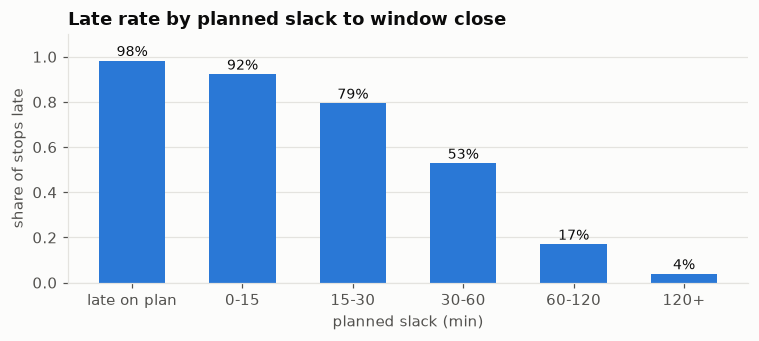

In [5]:
bands = pd.cut(route_f.planned_slack_min, [-np.inf, 0, 15, 30, 60, 120, np.inf],
               labels=["late on plan", "0-15", "15-30", "30-60", "60-120", "120+"])
late_by_band = stops.loc[train].groupby(bands[train], observed=True).late.mean()

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(late_by_band.index.astype(str), late_by_band.values, color=SERIES[0], width=0.6)
for i, v in enumerate(late_by_band.values):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center", color=INK, fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_title("Late rate by planned slack to window close")
ax.set_xlabel("planned slack (min)")
ax.set_ylabel("share of stops late")
plt.tight_layout()
plt.show()

Planned slack is the single clearest signal for lateness, but even stops with one to two hours of slack are sometimes late. The plan is optimistic, so slack on paper is not slack on the road. Section 6 corrects it with history.